### Function to find kmers in sequence

In [4]:
import math

def find_kmers(sequence):
    sequence = sequence.upper()
    kmers_dict = {}
    l = len(sequence)
    for k in range(1, 8):
        max_kmers = l - k + 1
        kmers = set()
        for i in range(max_kmers):
            kmer = sequence[i:i + k]
            kmers.add(kmer)
        if 4**k <= max_kmers:
            kmers_dict[k] = len(kmers) / (4**k)
        else:
            kmers_dict[k] = len(kmers) / max_kmers
    return kmers_dict

#### Retrieve the whole Chr1 from hg38 genome

In [2]:
# Creating "data_assignment/" directory
import os

path = "./data_assignment"
# Check if path exists
if not os.path.exists(path):
    # Create the directory
    os.makedirs(path)
    print(path, "directory created")
else:
    print(path, "directory exists")

./data_assignment directory exists


In [3]:
# Check if human Chr1 hg38 file exists
fasta_path = './data_assignment/chr1.fa.gz'
if not os.path.exists(fasta_path):
    print("File does not exist. Downloading fasta file.")
    os.system('wget -q -O ./data_assignment/chr1.fa.gz "https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr1.fa.gz"')
else:
    print("File already exists. Skipping download.")

File already exists. Skipping download.


In [ ]:
!gunzip ./data_assignment/chr1.fa.gz

In [6]:
# Read FASTA and clean sequence
with open("./data_assignment/chr1.fa", 'r') as file:
    raw = file.read().upper()
    dna_seq = ''.join(base for base in raw if base in {'A', 'T', 'C', 'G'})

### Create BED file to store complexity per window

In [7]:
# Sliding window parameters
window_size = 500
step = 100

# Write complexity to BED file
with open("complexity_windows.bed", "w") as bedfile:
    for j in range(0, len(dna_seq) - window_size + 1, step):
        window = dna_seq[j:j + window_size]
        kmers = find_kmers(window)
        complexity_values = list(kmers.values())
        complexity_score = math.prod(complexity_values)
        bedfile.write(f"chr1\t{j}\t{j + window_size}\t{complexity_score:.4f}\n") #store complexity rounded in 4 decimals in bed format

### Obtain genome annotations

#### - Obtain BED file with CDS annotation (ENSEMBL)

In [ ]:
# Check if human Chr1 with CDS hg38 anottation file exists
fasta_path = './data_assignment/Homo_sapiens.GRCh38.114.chromosome.1.gff3.gz'
if not os.path.exists(fasta_path):
    print("File does not exist. Downloading fasta file.")
    os.system('wget -q -O ./data_assignment/Homo_sapiens.GRCh38.114.chromosome.1.gff3.gz "https://ftp.ensembl.org/pub/release-114/gff3/homo_sapiens/Homo_sapiens.GRCh38.114.chromosome.1.gff3.gz"')
else:
    print("File already exists. Skipping download.")

In [6]:
%%bash

gunzip ./data_assignment/Homo_sapiens.GRCh38.114.chromosome.1.gff3.gz
sed -i 's/^chr//' complexity_windows.bed #strip 'chr' from bed file to match ENSEMBL annotation
bedtools intersect -a complexity_windows.bed -b Homo_sapiens.GRCh38.114.chromosome.1.gff3 -wa > complexity_in_cds.bed #cds annotation

#### - Obtain BED file with Repeat Sequence annotation (RepeatMasker from UCSC)

In [ ]:
#missing code to download repeat annotated file instantly

In [ ]:
%%bash

gunzip ./data_assignment/repeats_chr1.bed.gz
awk '{OFS="\t"; print $6, $7, $8, $10}' repeats_chr1.bed > repeats_chr1_clean.bed
tail -n +2 repeats_chr1_clean.bed > repeats_chr1_clean_noheader.bed
bedtools intersect -a complexity_windows.bed -b repeats_chr1_clean_noheader.bed -wa > complexity_in_repeats.bed

In [24]:
# !sed -i 's/^chr//' repeats_chr1_clean_noheader.bed

### Plot complexity distribution (needs more work...)

In [35]:
def load_complexity_scores(bed_file):
    scores = []
    with open(bed_file) as f:
        for line in f:
            fields = line.strip().split('\t')
            try:
                score = float(fields[3])
                scores.append(score)
            except:
                continue
    return scores

complexity_all = load_complexity_scores("complexity_windows.bed")
complexity_cds = load_complexity_scores("cds_windows.bed")
complexity_repeats = load_complexity_scores("repeats_windows.bed")

FileNotFoundError: [Errno 2] No such file or directory: 'cds_windows.bed'

In [37]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 6.2 MB/s eta 0:00:0000:0100:01


In [31]:
!pip install scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 38.6/38.6 MB 2.2 MB/s eta 0:00:0000:0100:01


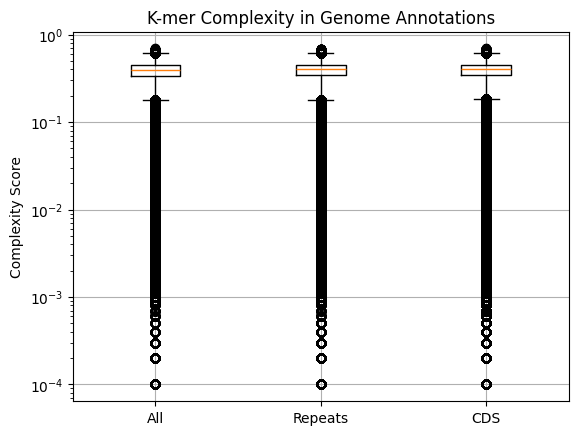

In [27]:
import matplotlib.pyplot as plt

def read_scores(filename):
    with open(filename) as f:
        return [float(line.strip().split()[3]) for line in f]

all_scores = read_scores("complexity_windows.bed")
repeat_scores = read_scores("complexity_in_repeats.bed")
cds_scores = read_scores("complexity_in_cds.bed")

plt.boxplot([all_scores, repeat_scores, cds_scores],
            tick_labels=["All", "Repeats", "CDS"])
plt.ylabel("Complexity Score")
plt.title("K-mer Complexity in Genome Annotations")
plt.grid(True)
plt.yscale('log')
plt.show()

/tmp/ipykernel_9861/1824477467.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([cds, non_cds], labels=["CDS", "non-CDS"], patch_artist=True)


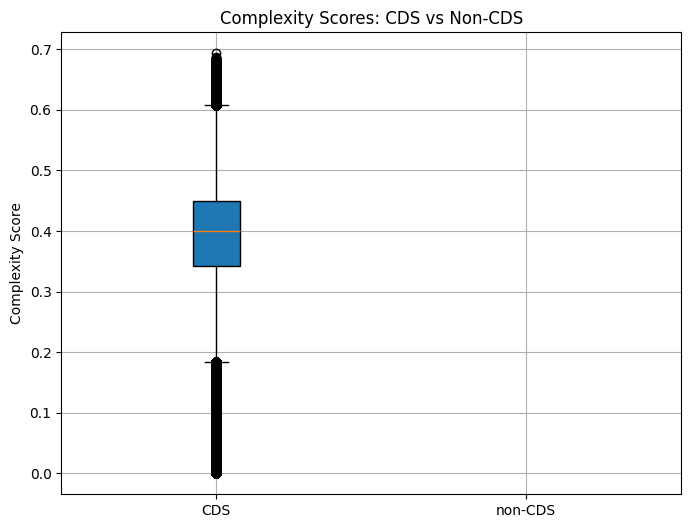

ValueError: `x` and `y` must be of nonzero size.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu

# Load BED files
all_scores = pd.read_csv("complexity_windows.bed", sep="\t", header=None, names=["chr", "start", "end", "score"])
cds_scores = pd.read_csv("complexity_in_cds.bed", sep="\t", header=None, names=["chr", "start", "end", "score"])

# Convert CDS regions to a set of tuples for fast lookup
cds_regions = set((row.start, row.end) for _, row in cds_scores.iterrows())

# Filter to get non-CDS regions
non_cds_scores = all_scores[~all_scores.apply(lambda row: (row.start, row.end) in cds_regions, axis=1)]

# Extract score arrays
cds = cds_scores["score"]
non_cds = non_cds_scores["score"]

# Plot boxplot
plt.figure(figsize=(8, 6))
plt.boxplot([cds, non_cds], labels=["CDS", "non-CDS"], patch_artist=True)
plt.ylabel("Complexity Score")
plt.title("Complexity Scores: CDS vs Non-CDS")
plt.grid(True)
plt.show()

# Mann-Whitney U Test
stat, pval = mannwhitneyu(cds, non_cds, alternative='two-sided')
print(f"Mann–Whitney U Test: U={stat:.2f}, p-value={pval:.4e}")
